# Order Delivery Time Prediction

## Objectives
The objective of this assignment is to build a regression model that predicts the delivery time for orders placed through Porter. The model will use various features such as the items ordered, the restaurant location, the order protocol, and the availability of delivery partners.

The key goals are:
- Predict the delivery time for an order based on multiple input features
- Improve delivery time predictions to optimiae operational efficiency
- Understand the key factors influencing delivery time to enhance the model's accuracy

## Data Pipeline
The data pipeline for this assignment will involve the following steps:
1. **Data Loading**
2. **Data Preprocessing and Feature Engineering**
3. **Exploratory Data Analysis**
4. **Model Building**
5. **Model Inference**

## Data Understanding
The dataset contains information on orders placed through Porter, with the following columns:

| Field                     | Description                                                                                 |
|---------------------------|---------------------------------------------------------------------------------------------|
| market_id                 | Integer ID representing the market where the restaurant is located.                         |
| created_at                | Timestamp when the order was placed.                                                        |
| actual_delivery_time      | Timestamp when the order was delivered.                                                     |
| store_primary_category    | Category of the restaurant (e.g., fast food, dine-in).                                      |
| order_protocol            | Integer representing how the order was placed (e.g., via Porter, call to restaurant, etc.). |
| total_items               | Total number of items in the order.                                                         |
| subtotal                  | Final price of the order.                                                                   |
| num_distinct_items        | Number of distinct items in the order.                                                      |
| min_item_price            | Price of the cheapest item in the order.                                                    |
| max_item_price            | Price of the most expensive item in the order.                                              |
| total_onshift_dashers     | Number of delivery partners on duty when the order was placed.                              |
| total_busy_dashers        | Number of delivery partners already occupied with other orders.                             |
| total_outstanding_orders  | Number of orders pending fulfillment at the time of the order.                              |
| distance                  | Total distance from the restaurant to the customer.                                         |


## **Importing Necessary Libraries**

In [ ]:
# Import essential libraries for data manipulation and analysis



## **1. Loading the data**
Load 'porter_data_1.csv' as a DataFrame

In [4]:
# Importing the file porter_data_1.csv
import pandas as pd
df = pd.read_csv('porter_data_1.csv')
#print(df.head())

## **2. Data Preprocessing and Feature Engineering** <font color = red>[15 marks]</font> <br>

#### **2.1 Fixing the Datatypes**  <font color = red>[5 marks]</font> <br>
The current timestamps are in object format and need conversion to datetime format for easier handling and intended functionality

##### **2.1.1** <font color = red>[2 marks]</font> <br>
Convert date and time fields to appropriate data type

In [5]:
# Convert 'created_at' and 'actual_delivery_time' columns to datetime format

import pandas as pd

# Load the CSV file
df = pd.read_csv('porter_data_1.csv')


df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])


print(df.dtypes[['created_at', 'actual_delivery_time']])




created_at              datetime64[ns]
actual_delivery_time    datetime64[ns]
dtype: object


##### **2.1.2**  <font color = red>[3 marks]</font> <br>
Convert categorical fields to appropriate data type

In [6]:
# Convert categorical features to category type

import pandas as pd

# Load the CSV file
df = pd.read_csv('porter_data_1.csv')


df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])


potential_categoricals = df.select_dtypes(include=['object']).columns.tolist()


for col in df.select_dtypes(include=['int64', 'float64']).columns:
    if df[col].nunique() <= 20:
        potential_categoricals.append(col)


potential_categoricals = list(set(potential_categoricals))
df[potential_categoricals] = df[potential_categoricals].astype('category')

# (Optional) Display updated data types of converted columns
print(df.dtypes[potential_categoricals])



order_protocol        category
market_id             category
num_distinct_items    category
dtype: object


#### **2.2 Feature Engineering** <font color = red>[5 marks]</font> <br>
Calculate the time taken to execute the delivery as well as extract the hour and day at which the order was placed

##### **2.2.1** <font color = red>[2 marks]</font> <br>
Calculate the time taken using the features `actual_delivery_time` and `created_at`

In [7]:
# Calculate time taken in minutes
import pandas as pd


df = pd.read_csv('porter_data_1.csv')


df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])


df['time_taken_minutes'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60


print(df[['created_at', 'actual_delivery_time', 'time_taken_minutes']].head())


           created_at actual_delivery_time  time_taken_minutes
0 2015-02-06 22:24:17  2015-02-06 23:11:17                47.0
1 2015-02-10 21:49:25  2015-02-10 22:33:25                44.0
2 2015-02-16 00:11:35  2015-02-16 01:06:35                55.0
3 2015-02-12 03:36:46  2015-02-12 04:35:46                59.0
4 2015-01-27 02:12:36  2015-01-27 02:58:36                46.0


##### **2.2.2** <font color = red>[3 marks]</font> <br>
Extract the hour at which the order was placed and which day of the week it was. Drop the unnecessary columns.

In [10]:
# Extract the hour and day of week from the 'created_at' timestamp


# Create a categorical feature 'isWeekend'

import pandas as pd

# Load the CSV file
df = pd.read_csv('porter_data_1.csv')

# Convert to datetime
df['created_at'] = pd.to_datetime(df['created_at'])

# Extract hour and day of week
df['created_hour'] = df['created_at'].dt.hour
df['created_day_of_week'] = df['created_at'].dt.dayofweek  # Monday=0, Sunday=6


print(df[['created_at', 'created_hour', 'created_day_of_week']].head())



df['created_day_of_week'] = df['created_at'].dt.dayofweek  # Monday=0, Sunday=6


df['isWeekend'] = df['created_day_of_week'].apply(lambda x: 'Yes' if x >= 5 else 'No')
df['isWeekend'] = df['isWeekend'].astype('category')


print(df[['created_at', 'created_day_of_week', 'isWeekend']].head())


           created_at  created_hour  created_day_of_week
0 2015-02-06 22:24:17            22                    4
1 2015-02-10 21:49:25            21                    1
2 2015-02-16 00:11:35             0                    0
3 2015-02-12 03:36:46             3                    3
4 2015-01-27 02:12:36             2                    1
           created_at  created_day_of_week isWeekend
0 2015-02-06 22:24:17                    4        No
1 2015-02-10 21:49:25                    1        No
2 2015-02-16 00:11:35                    0        No
3 2015-02-12 03:36:46                    3        No
4 2015-01-27 02:12:36                    1        No


In [11]:
# Drop unnecessary columns
import pandas as pd

# Load and process data
df = pd.read_csv('porter_data_1.csv')
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])
df['created_day_of_week'] = df['created_at'].dt.dayofweek
df['isWeekend'] = df['created_day_of_week'].apply(lambda x: 'Yes' if x >= 5 else 'No')
df['isWeekend'] = df['isWeekend'].astype('category')
df['created_hour'] = df['created_at'].dt.hour
df['time_taken_minutes'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60


columns_to_drop = ['created_at', 'actual_delivery_time', 'created_day_of_week']
df.drop(columns=columns_to_drop, inplace=True)


print(df.columns)


Index(['market_id', 'store_primary_category', 'order_protocol', 'total_items',
       'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_dashers', 'total_busy_dashers',
       'total_outstanding_orders', 'distance', 'isWeekend', 'created_hour',
       'time_taken_minutes'],
      dtype='object')


#### **2.3 Creating training and validation sets** <font color = red>[5 marks]</font> <br>

##### **2.3.1** <font color = red>[2 marks]</font> <br>
 Define target and input features

In [3]:
# Define target variable (y) and features (X)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


data = pd.read_csv("porter_data_1.csv")


data["created_at"] = pd.to_datetime(data["created_at"])
data["actual_delivery_time"] = pd.to_datetime(data["actual_delivery_time"])


data["delivery_duration"] = (data["actual_delivery_time"] - data["created_at"]).dt.total_seconds() / 60.0


target = "delivery_duration"


drop_cols = ["actual_delivery_time", "delivery_duration"]
X = data.drop(columns=drop_cols + ["created_at"])  # optionally extract time features instead


X["store_primary_category"] = LabelEncoder().fit_transform(X["store_primary_category"])


y = data[target]


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}")


Train shape: (140621, 12), Validation shape: (35156, 12)


##### **2.3.2** <font color = red>[3 marks]</font> <br>
 Split the data into training and test sets

In [5]:
# Split data into training and testing sets

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


data = pd.read_csv("porter_data_1.csv")


data["created_at"] = pd.to_datetime(data["created_at"])
data["actual_delivery_time"] = pd.to_datetime(data["actual_delivery_time"])


data["delivery_duration"] = (data["actual_delivery_time"] - data["created_at"]).dt.total_seconds() / 60.0


features = [
    "market_id", "store_primary_category", "order_protocol",
    "total_items", "subtotal", "num_distinct_items",
    "min_item_price", "max_item_price",
    "total_onshift_dashers", "total_busy_dashers",
    "total_outstanding_orders", "distance"
]

X = data[features]
y = data["delivery_duration"]


X = X.copy()
X["store_primary_category"] = LabelEncoder().fit_transform(X["store_primary_category"])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Output confirmation
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)




Training set size: (140621, 12)
Testing set size: (35156, 12)


## **3. Exploratory Data Analysis on Training Data** <font color = red>[20 marks]</font> <br>
1. Analyzing the correlation between variables to identify patterns and relationships
2. Identifying and addressing outliers to ensure the integrity of the analysis
3. Exploring the relationships between variables and examining the distribution of the data for better insights

#### **3.1 Feature Distributions** <font color = red> [7 marks]</font> <br>


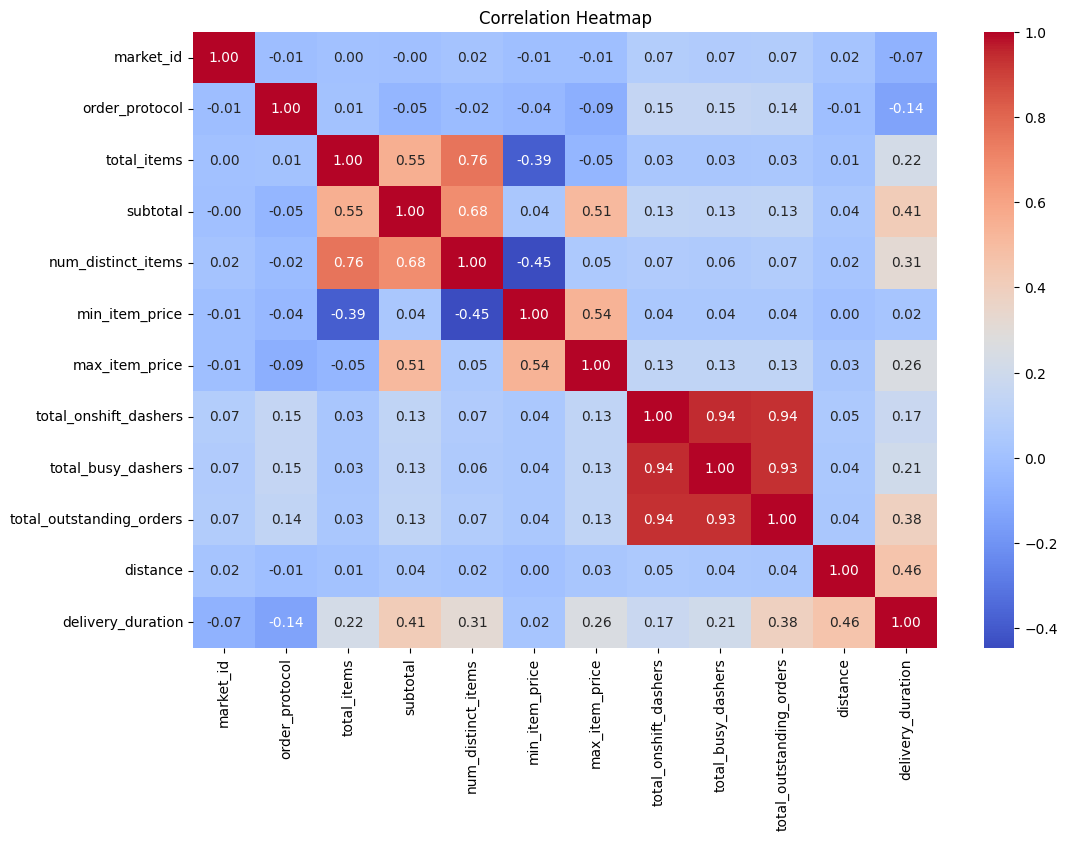

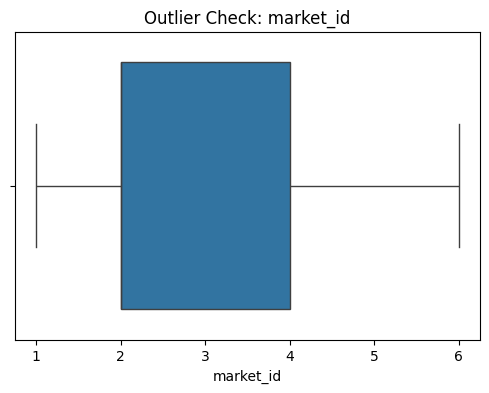

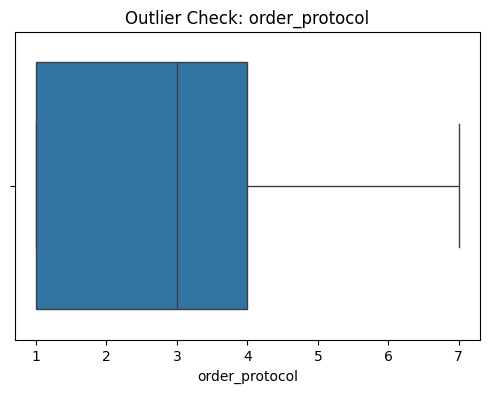

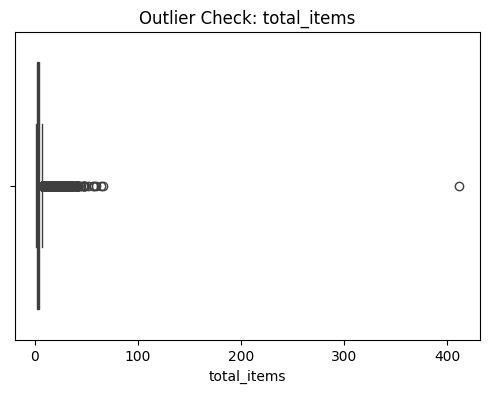

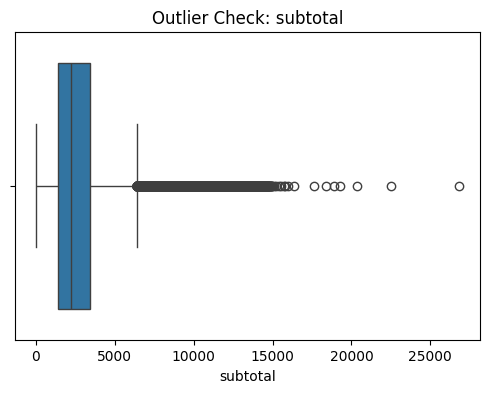

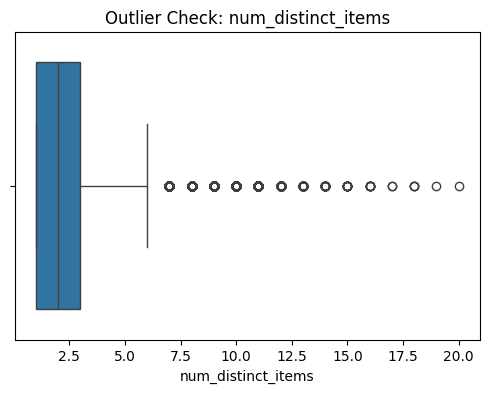

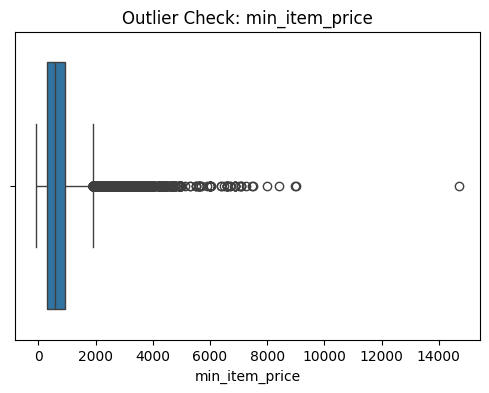

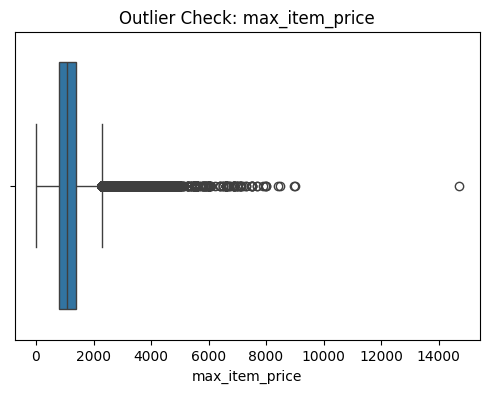

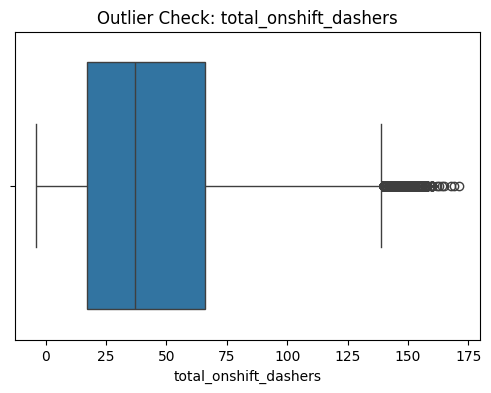

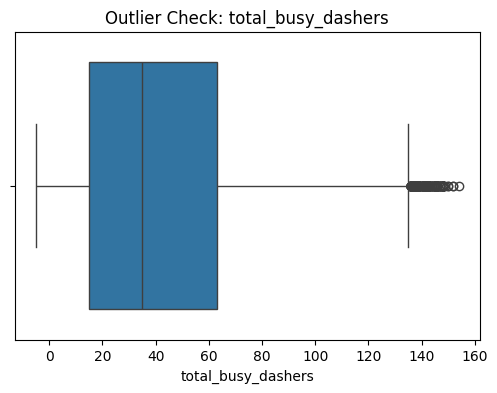

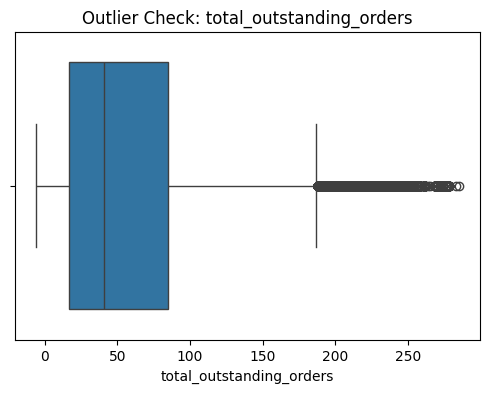

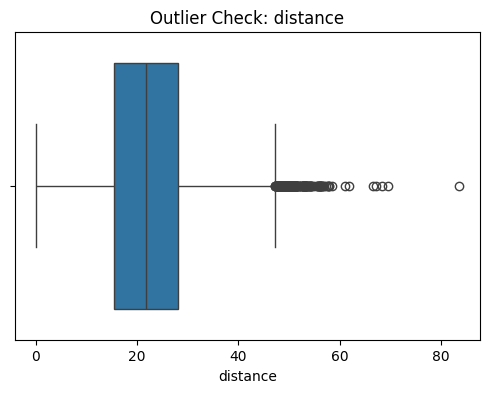

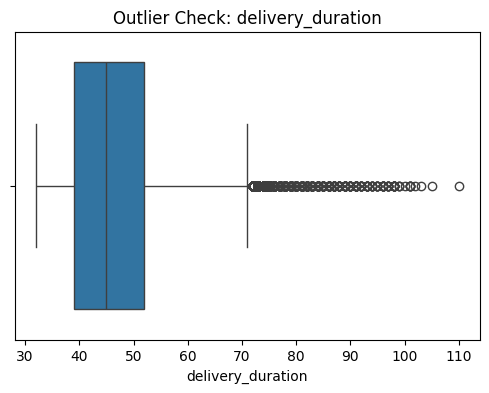

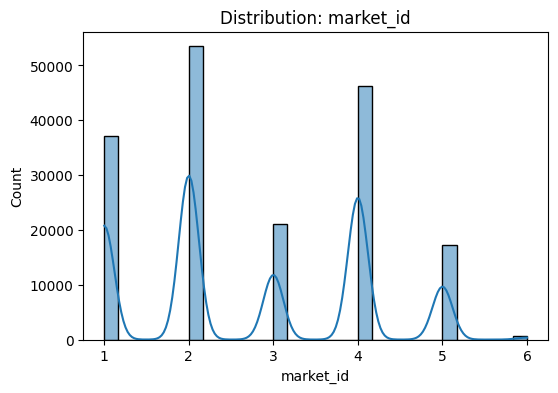

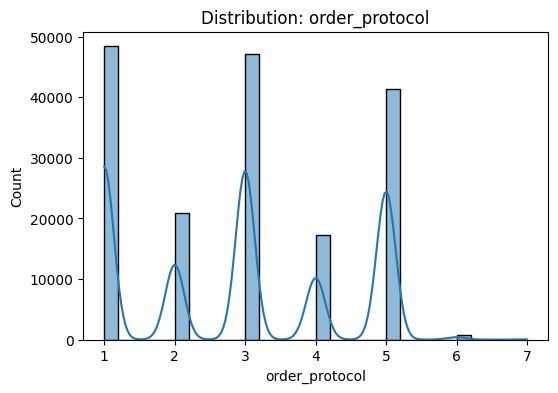

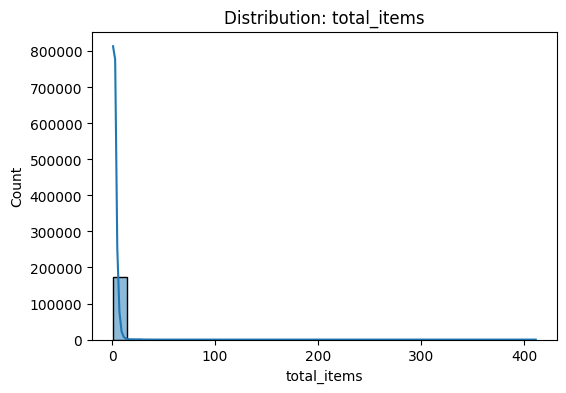

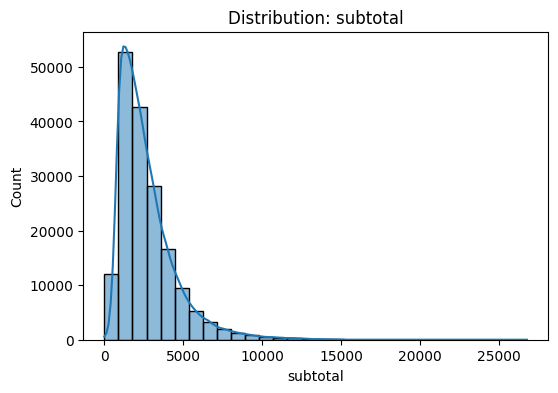

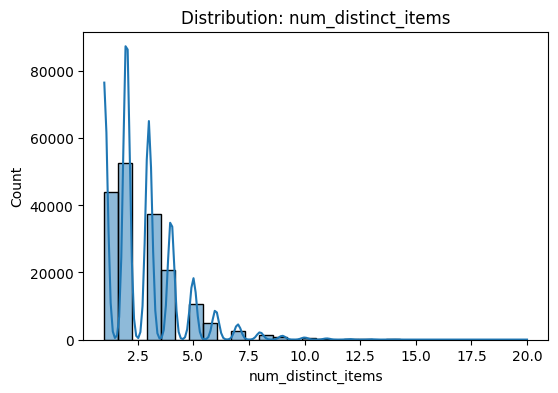

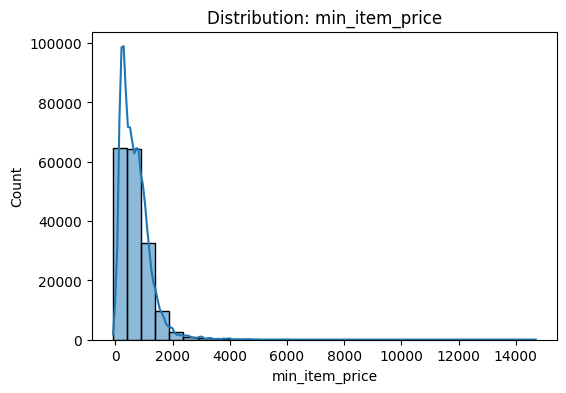

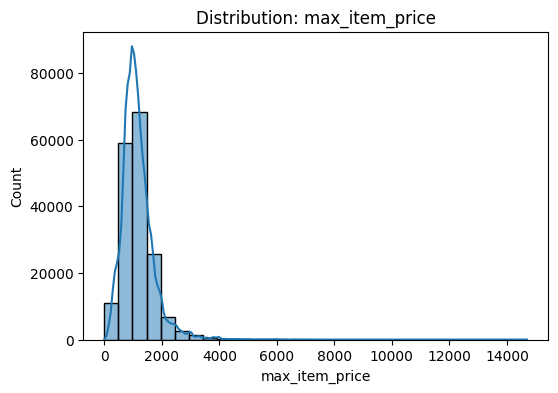

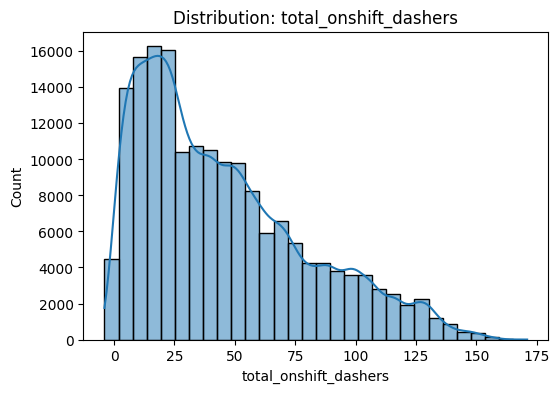

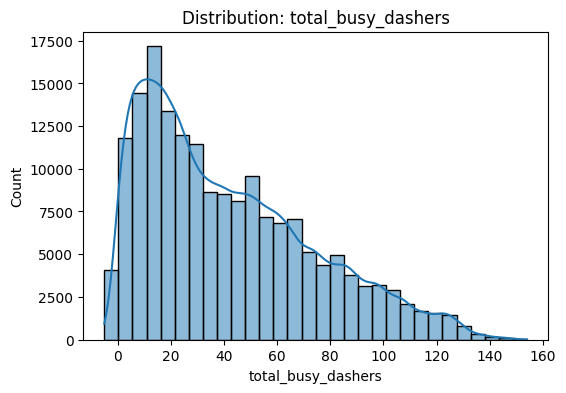

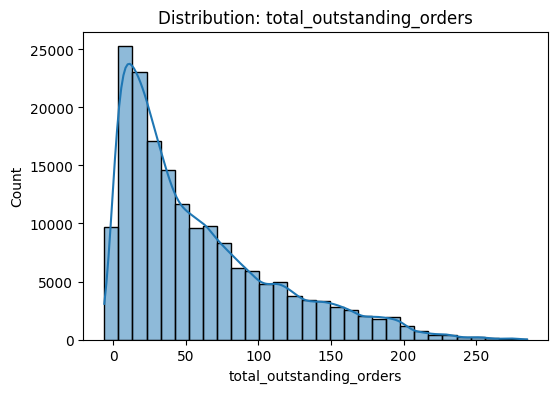

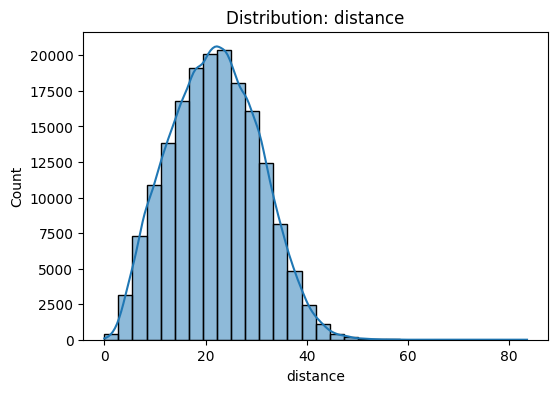

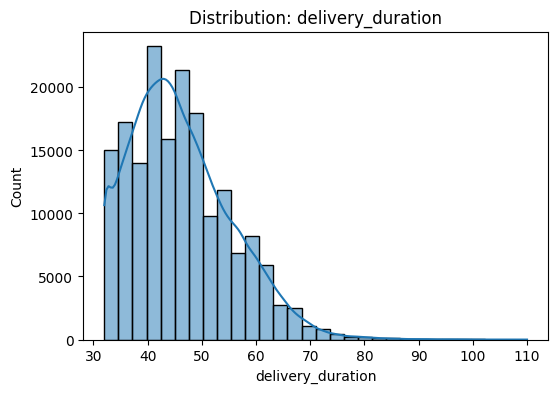

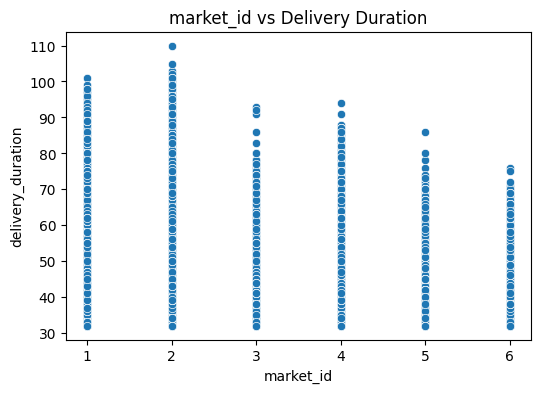

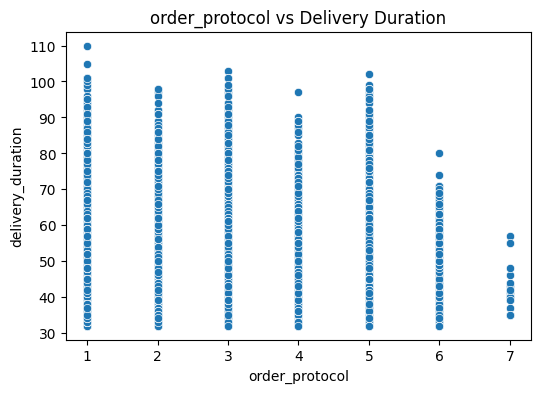

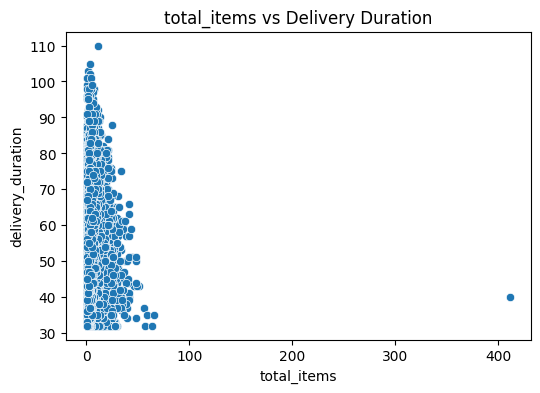

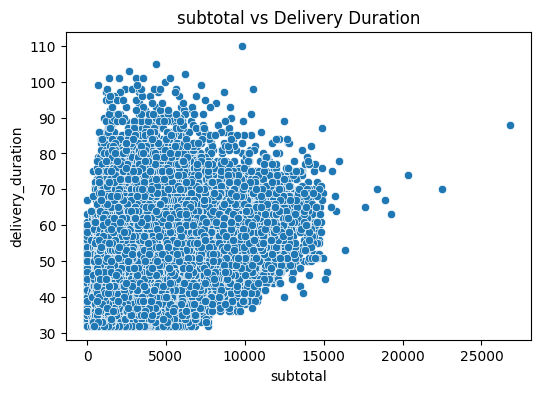

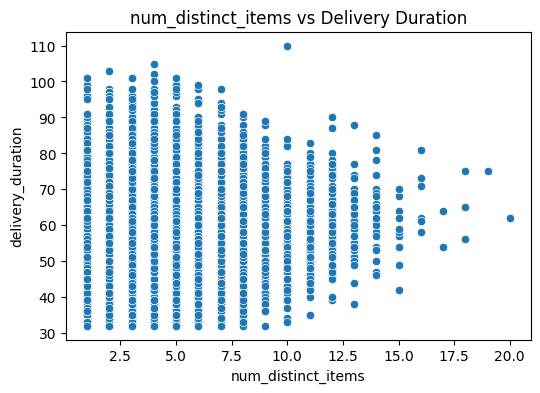

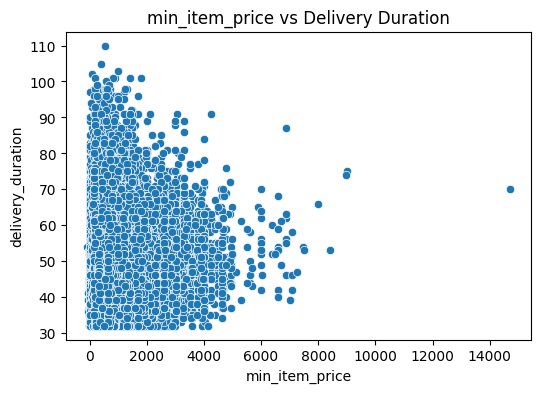

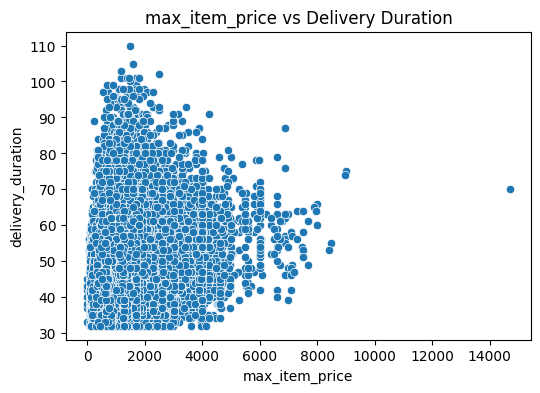

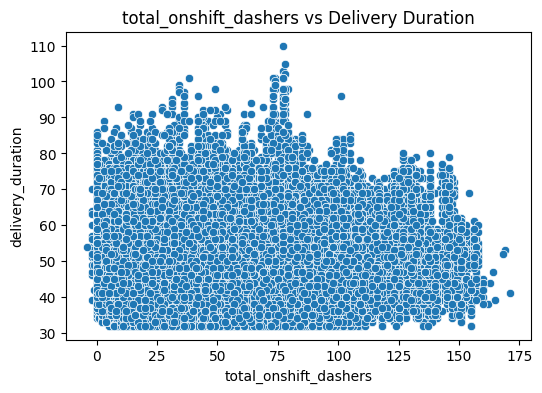

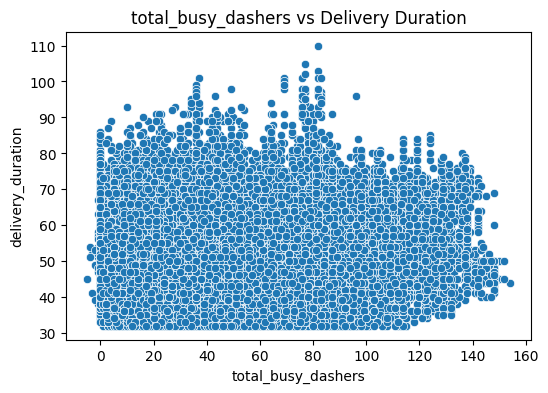

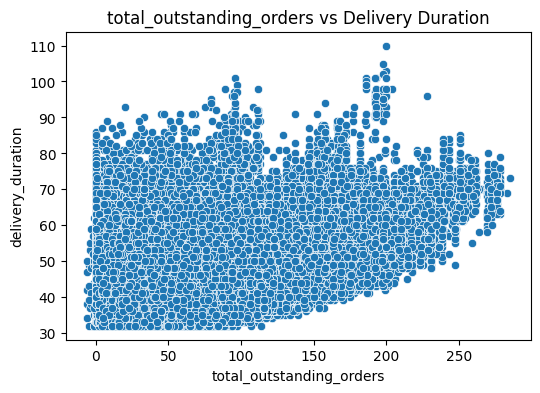

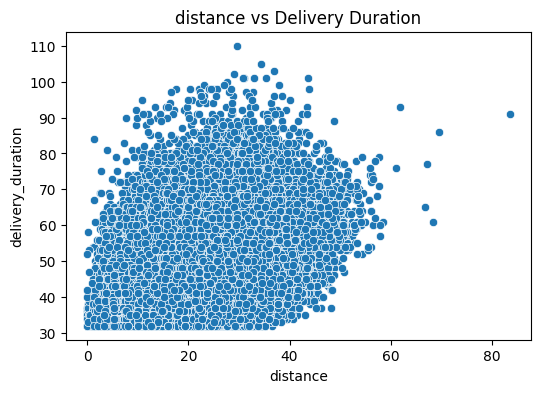

In [8]:
# Define numerical and categorical columns for easy EDA and data manipulation

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


data = pd.read_csv("porter_data_1.csv")
data["created_at"] = pd.to_datetime(data["created_at"])
data["actual_delivery_time"] = pd.to_datetime(data["actual_delivery_time"])
data["delivery_duration"] = (data["actual_delivery_time"] - data["created_at"]).dt.total_seconds() / 60.0


numerical_cols = [
    "market_id", "order_protocol", "total_items", "subtotal",
    "num_distinct_items", "min_item_price", "max_item_price",
    "total_onshift_dashers", "total_busy_dashers", "total_outstanding_orders",
    "distance", "delivery_duration"
]
categorical_cols = ["store_primary_category"]


label_encoder = LabelEncoder()
data["store_primary_category_encoded"] = label_encoder.fit_transform(data["store_primary_category"])


plt.figure(figsize=(12, 8))
corr = data[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data[col])
    plt.title(f"Outlier Check: {col}")
    plt.show()


for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f"Distribution: {col}")
    plt.show()


for col in numerical_cols:
    if col != "delivery_duration":
        plt.figure(figsize=(6, 4))
        sns.scatterplot(data=data, x=col, y="delivery_duration")
        plt.title(f"{col} vs Delivery Duration")
        plt.show()



##### **3.1.1** <font color = red>[3 marks]</font> <br>
Plot distributions for numerical columns in the training set to understand their spread and any skewness

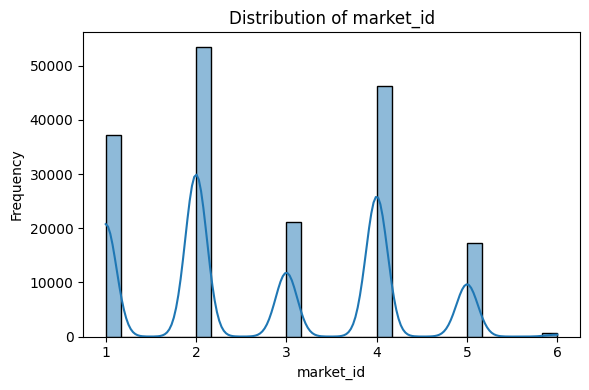

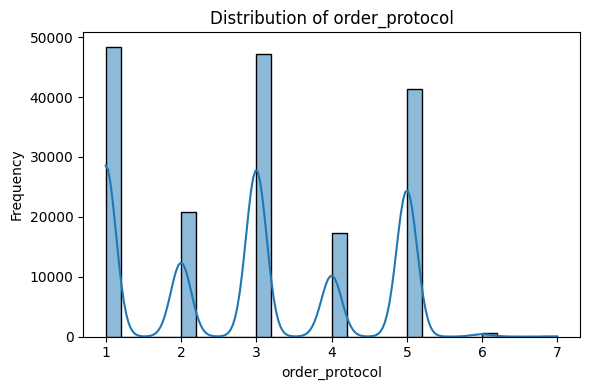

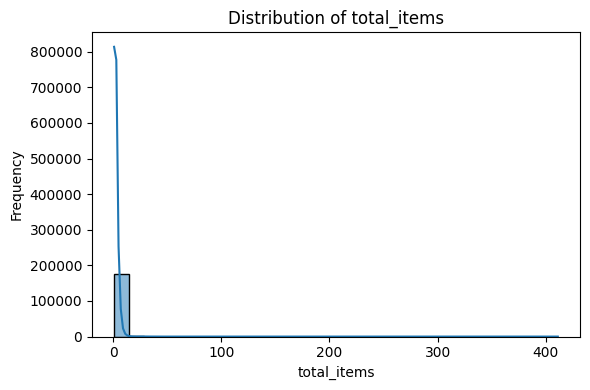

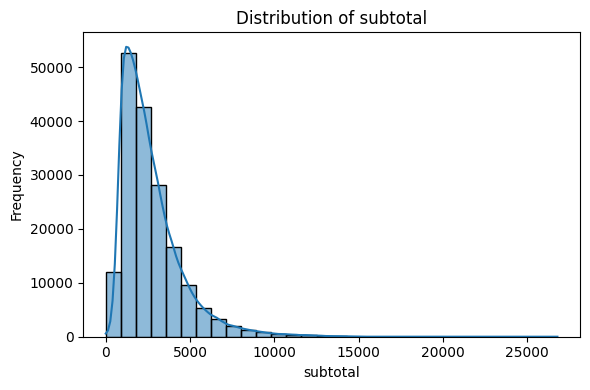

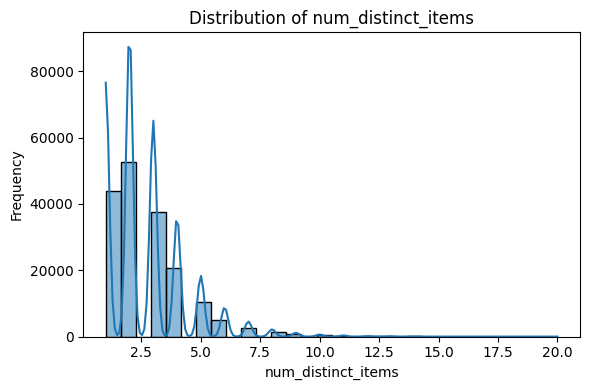

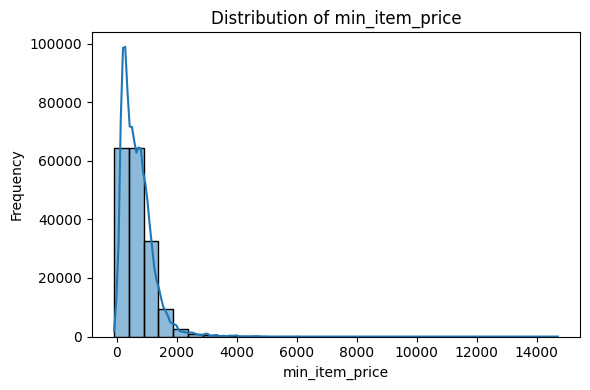

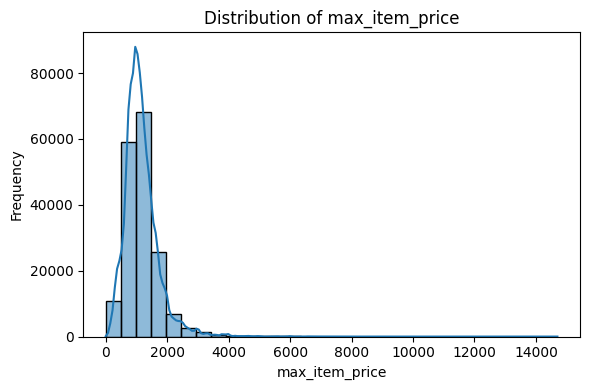

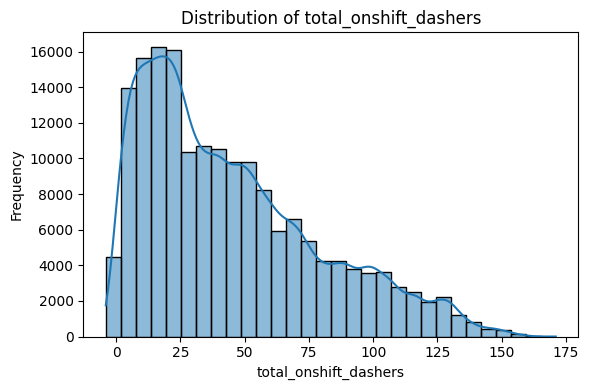

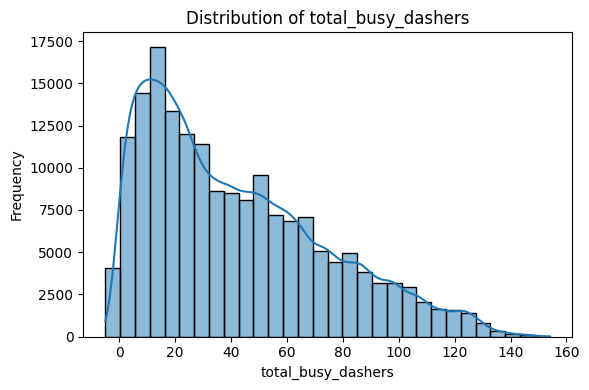

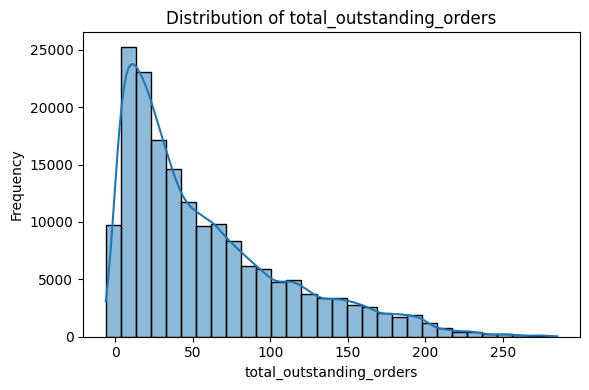

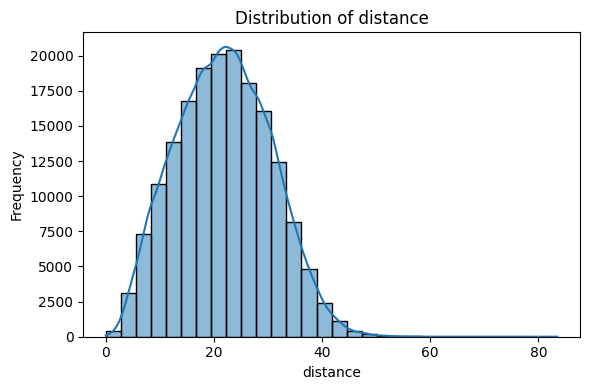

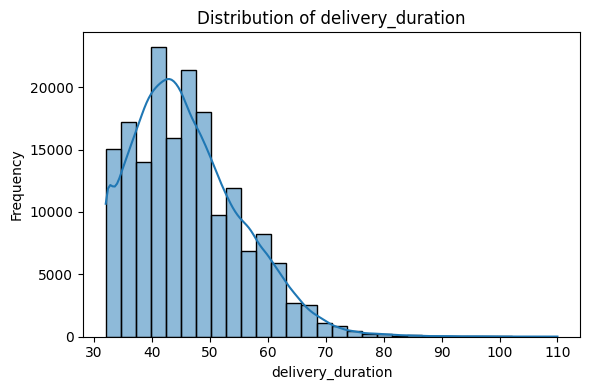

In [9]:
# Plot distributions for all numerical columns

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


data = pd.read_csv("porter_data_1.csv")


data["created_at"] = pd.to_datetime(data["created_at"])
data["actual_delivery_time"] = pd.to_datetime(data["actual_delivery_time"])


data["delivery_duration"] = (data["actual_delivery_time"] - data["created_at"]).dt.total_seconds() / 60.0


numerical_cols = [
    "market_id", "order_protocol", "total_items", "subtotal",
    "num_distinct_items", "min_item_price", "max_item_price",
    "total_onshift_dashers", "total_busy_dashers", "total_outstanding_orders",
    "distance", "delivery_duration"
]


for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()



##### **3.1.2** <font color = red>[2 marks]</font> <br>
Check the distribution of categorical features

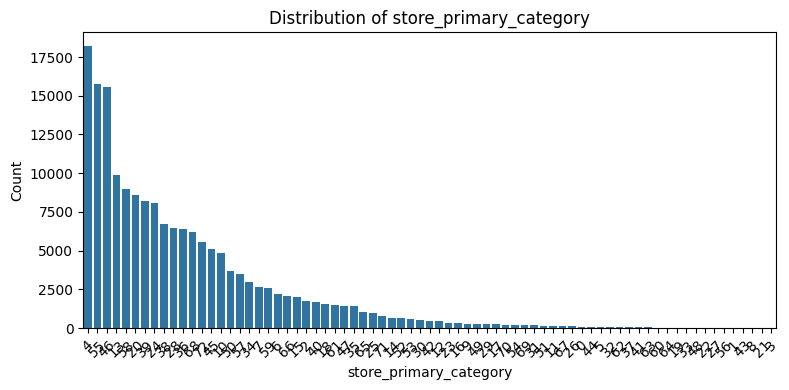

In [10]:
# Distribution of categorical columns

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


data = pd.read_csv("porter_data_1.csv")


categorical_cols = ["store_primary_category"]


for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=data, x=col, order=data[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



##### **3.1.3** <font color = red>[2 mark]</font> <br>
Visualise the distribution of the target variable to understand its spread and any skewness

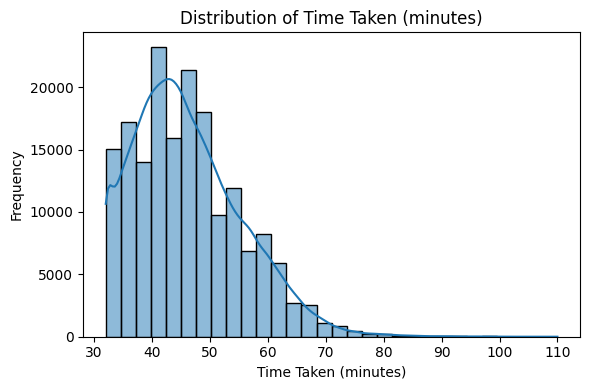

In [11]:
# Distribution of time_taken
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


data = pd.read_csv("porter_data_1.csv")


data["created_at"] = pd.to_datetime(data["created_at"])
data["actual_delivery_time"] = pd.to_datetime(data["actual_delivery_time"])


data["time_taken"] = (data["actual_delivery_time"] - data["created_at"]).dt.total_seconds() / 60.0


plt.figure(figsize=(6, 4))
sns.histplot(data["time_taken"], kde=True, bins=30)
plt.title("Distribution of Time Taken (minutes)")
plt.xlabel("Time Taken (minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



#### **3.2 Relationships Between Features** <font color = red>[3 marks]</font> <br>

##### **3.2.1** <font color = red>[3 marks]</font> <br>
Scatter plots for important numerical and categorical features to observe how they relate to `time_taken`

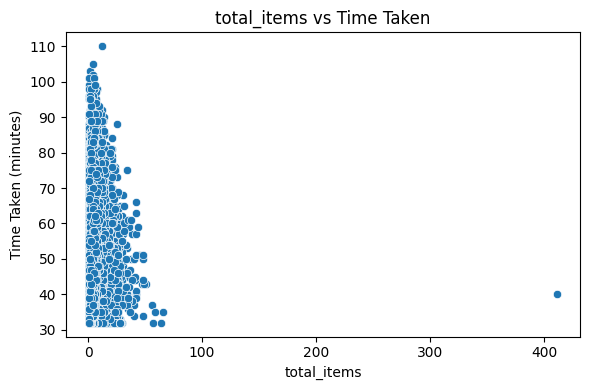

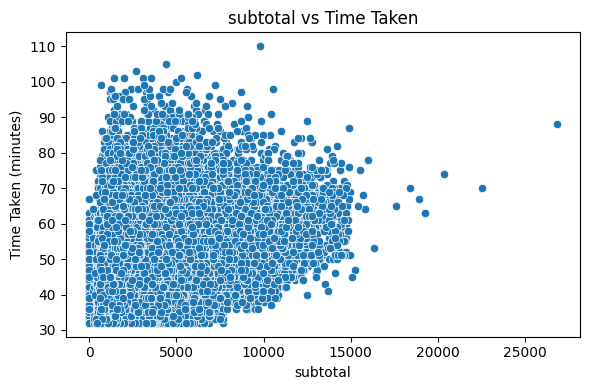

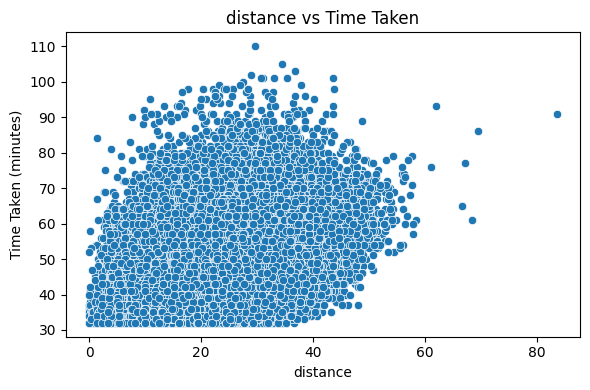

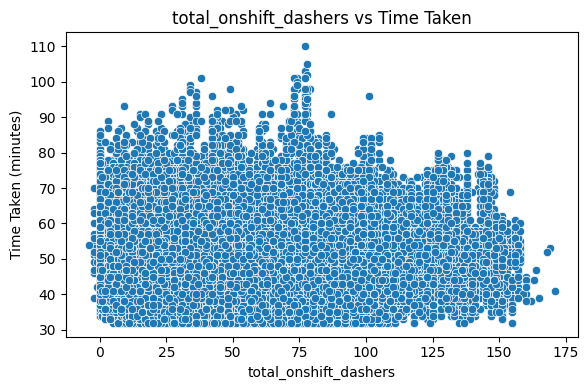

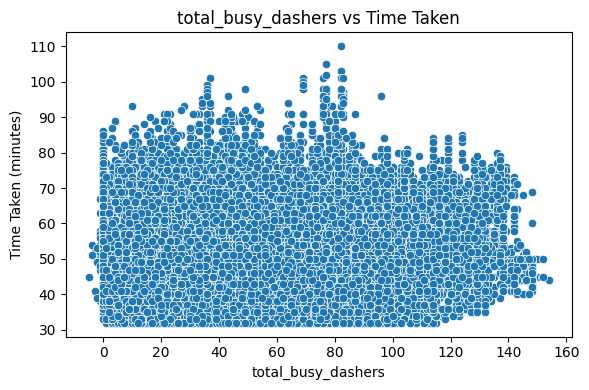

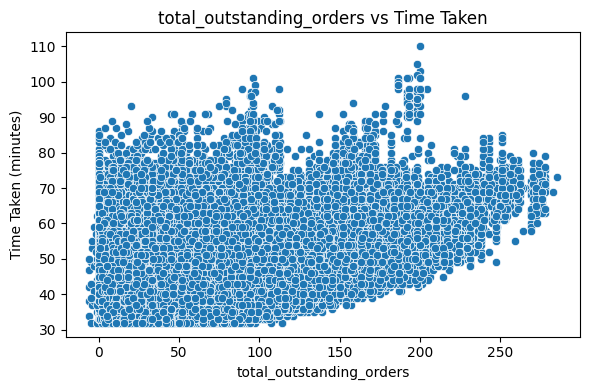

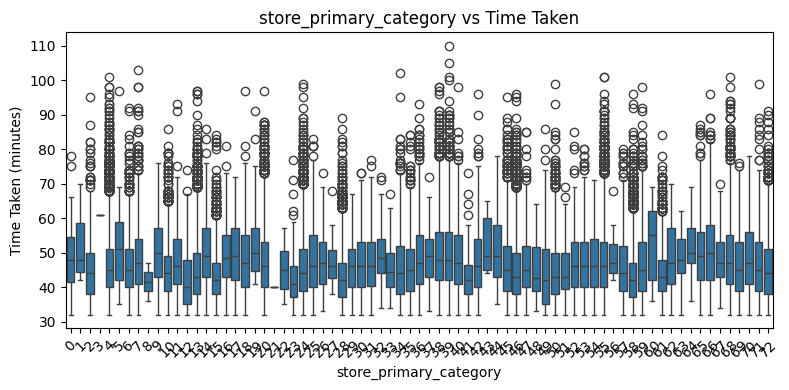

In [12]:
# Scatter plot to visualise the relationship between time_taken and other features

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


data = pd.read_csv("porter_data_1.csv")
data["created_at"] = pd.to_datetime(data["created_at"])
data["actual_delivery_time"] = pd.to_datetime(data["actual_delivery_time"])
data["time_taken"] = (data["actual_delivery_time"] - data["created_at"]).dt.total_seconds() / 60.0


numerical_features = [
    "total_items", "subtotal", "distance",
    "total_onshift_dashers", "total_busy_dashers", "total_outstanding_orders"
]
categorical_features = ["store_primary_category"]


for col in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=data, x=col, y="time_taken")
    plt.title(f"{col} vs Time Taken")
    plt.xlabel(col)
    plt.ylabel("Time Taken (minutes)")
    plt.tight_layout()
    plt.show()


for col in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=data, x=col, y="time_taken")
    plt.title(f"{col} vs Time Taken")
    plt.xlabel(col)
    plt.ylabel("Time Taken (minutes)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


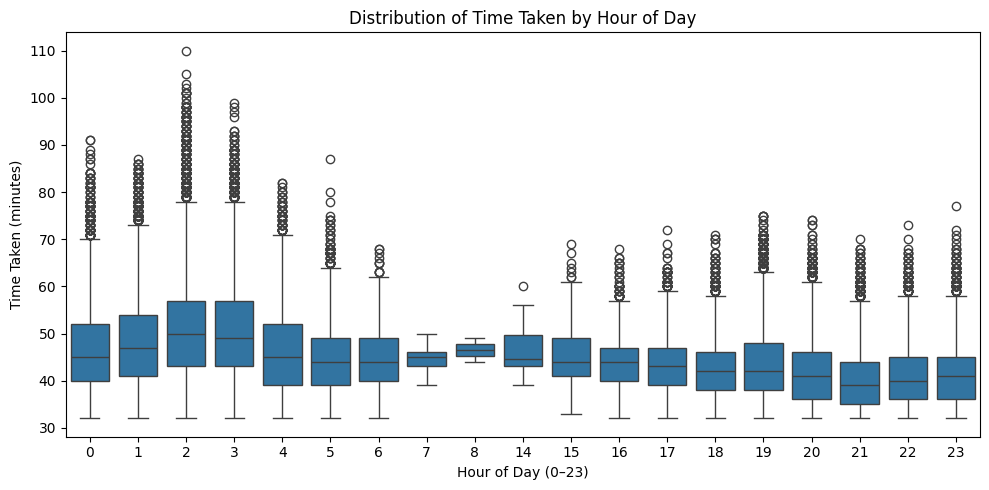

In [13]:
# Show the distribution of time_taken for different hours
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


data = pd.read_csv("porter_data_1.csv")
data["created_at"] = pd.to_datetime(data["created_at"])
data["actual_delivery_time"] = pd.to_datetime(data["actual_delivery_time"])
data["time_taken"] = (data["actual_delivery_time"] - data["created_at"]).dt.total_seconds() / 60.0


data["order_hour"] = data["created_at"].dt.hour


plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="order_hour", y="time_taken")
plt.title("Distribution of Time Taken by Hour of Day")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Time Taken (minutes)")
plt.tight_layout()
plt.show()



#### **3.3 Correlation Analysis** <font color = red>[5 marks]</font> <br>
Check correlations between numerical features to identify which variables are strongly related to `time_taken`

##### **3.3.1** <font color = red>[3 marks]</font> <br>
Plot a heatmap to display correlations

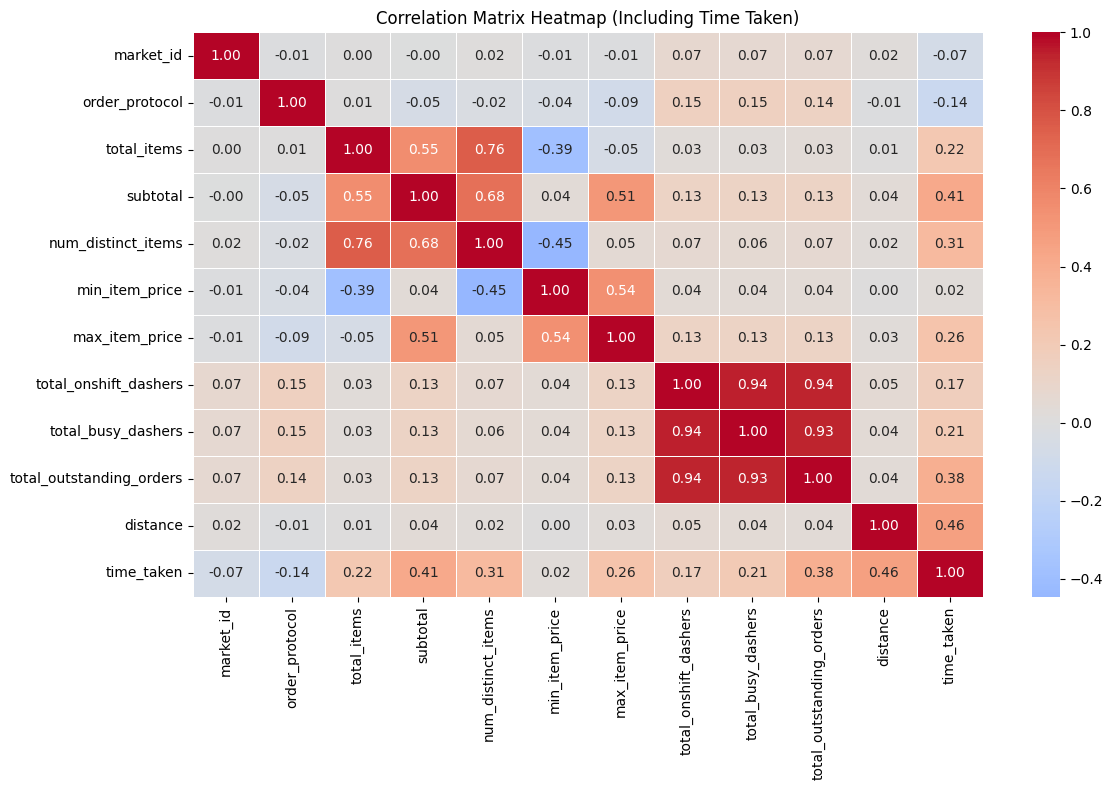

In [14]:
# Plot the heatmap of the correlation matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


data = pd.read_csv("porter_data_1.csv")
data["created_at"] = pd.to_datetime(data["created_at"])
data["actual_delivery_time"] = pd.to_datetime(data["actual_delivery_time"])
data["time_taken"] = (data["actual_delivery_time"] - data["created_at"]).dt.total_seconds() / 60.0


numerical_cols = [
    "market_id", "order_protocol", "total_items", "subtotal",
    "num_distinct_items", "min_item_price", "max_item_price",
    "total_onshift_dashers", "total_busy_dashers", "total_outstanding_orders",
    "distance", "time_taken"
]


corr_matrix = data[numerical_cols].corr()


plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Matrix Heatmap (Including Time Taken)")
plt.tight_layout()
plt.show()



##### **3.3.2** <font color = red>[2 marks]</font> <br>
Drop the columns with weak correlations with the target variable

In [15]:
# Drop 3-5 weakly correlated columns from training dataset

import pandas as pd


data = pd.read_csv("porter_data_1.csv")
data["created_at"] = pd.to_datetime(data["created_at"])
data["actual_delivery_time"] = pd.to_datetime(data["actual_delivery_time"])
data["time_taken"] = (data["actual_delivery_time"] - data["created_at"]).dt.total_seconds() / 60.0


numerical_cols = [
    "market_id", "order_protocol", "total_items", "subtotal",
    "num_distinct_items", "min_item_price", "max_item_price",
    "total_onshift_dashers", "total_busy_dashers", "total_outstanding_orders",
    "distance", "time_taken"
]


correlations = data[numerical_cols].corr()["time_taken"].drop("time_taken").sort_values()


print("Correlation of features with time_taken:")
print(correlations)


weak_features = correlations[correlations.abs() < 0.05].index.tolist()


weak_features = correlations.nsmallest(5).index.tolist()

print(f"\nDropping weakly correlated features: {weak_features}")


data_reduced = data.drop(columns=weak_features)




Correlation of features with time_taken:
order_protocol             -0.136755
market_id                  -0.073016
min_item_price              0.022753
total_onshift_dashers       0.171015
total_busy_dashers          0.206045
total_items                 0.224856
max_item_price              0.255167
num_distinct_items          0.312055
total_outstanding_orders    0.384999
subtotal                    0.413267
distance                    0.460173
Name: time_taken, dtype: float64

Dropping weakly correlated features: ['order_protocol', 'market_id', 'min_item_price', 'total_onshift_dashers', 'total_busy_dashers']


#### **3.4 Handling the Outliers** <font color = red>[5 marks]</font> <br>



##### **3.4.1** <font color = red>[2 marks]</font> <br>
Visualise potential outliers for the target variable and other numerical features using boxplots

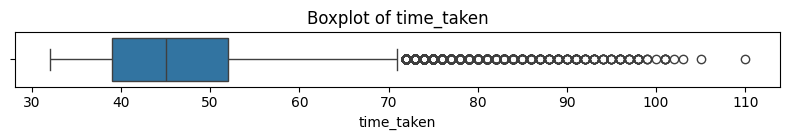

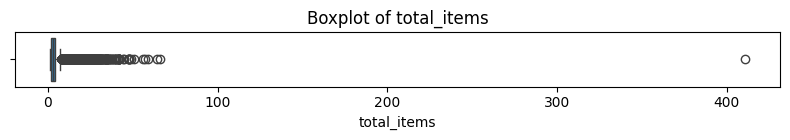

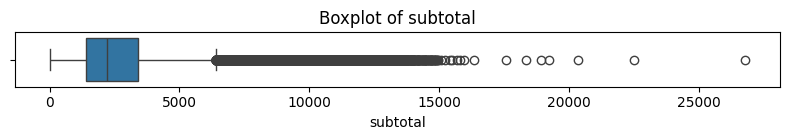

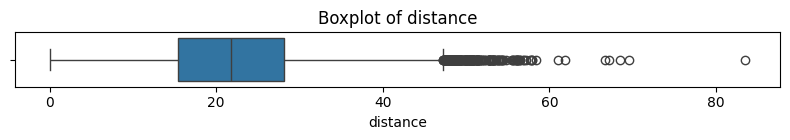

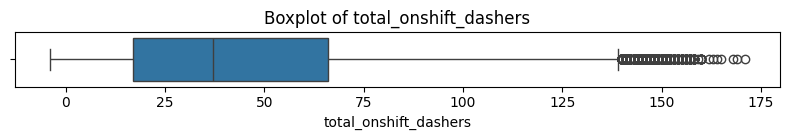

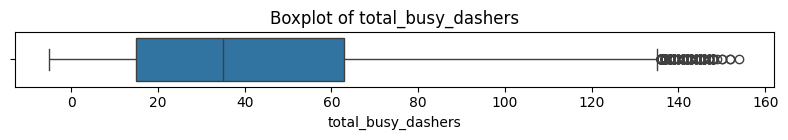

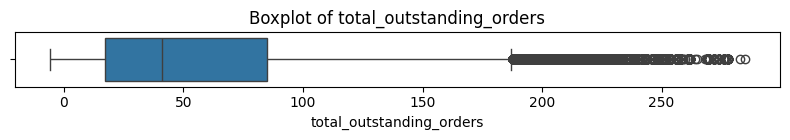

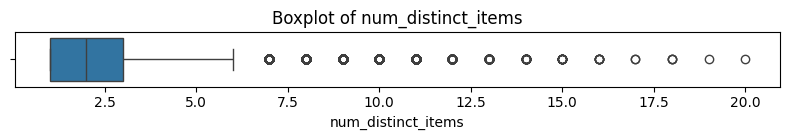

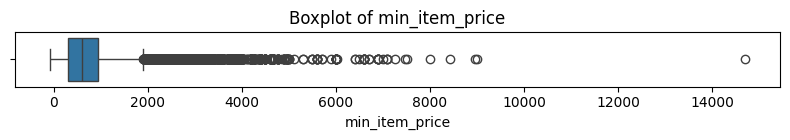

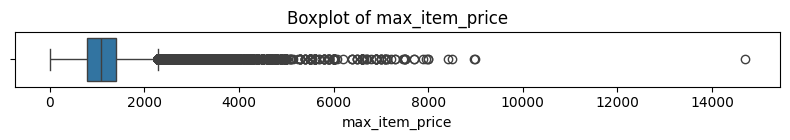

In [16]:
# Boxplot for time_taken
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


data = pd.read_csv("porter_data_1.csv")
data["created_at"] = pd.to_datetime(data["created_at"])
data["actual_delivery_time"] = pd.to_datetime(data["actual_delivery_time"])
data["time_taken"] = (data["actual_delivery_time"] - data["created_at"]).dt.total_seconds() / 60.0


numerical_cols = [
    "time_taken", "total_items", "subtotal", "distance",
    "total_onshift_dashers", "total_busy_dashers", "total_outstanding_orders",
    "num_distinct_items", "min_item_price", "max_item_price"
]


for col in numerical_cols:
    plt.figure(figsize=(8, 1.5))
    sns.boxplot(x=data[col], orient="h")
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()



##### **3.4.2** <font color = red>[3 marks]</font> <br>
Handle outliers present in all columns

In [17]:
# Handle outliers
import pandas as pd


data = pd.read_csv("porter_data_1.csv")
data["created_at"] = pd.to_datetime(data["created_at"])
data["actual_delivery_time"] = pd.to_datetime(data["actual_delivery_time"])
data["time_taken"] = (data["actual_delivery_time"] - data["created_at"]).dt.total_seconds() / 60.0


numerical_cols = [
    "time_taken", "total_items", "subtotal", "distance",
    "total_onshift_dashers", "total_busy_dashers", "total_outstanding_orders",
    "num_distinct_items", "min_item_price", "max_item_price"
]


for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

print("Outliers removed. Cleaned data shape:", data.shape)



Outliers removed. Cleaned data shape: (145165, 15)


## **4. Exploratory Data Analysis on Validation Data** <font color = red>[optional]</font> <br>
Optionally, perform EDA on test data to see if the distribution match with the training data

In [ ]:
# Define numerical and categorical columns for easy EDA and data manipulation



#### **4.1 Feature Distributions**


##### **4.1.1**
Plot distributions for numerical columns in the validation set to understand their spread and any skewness

In [ ]:
# Plot distributions for all numerical columns



##### **4.1.2**
Check the distribution of categorical features

In [ ]:
# Distribution of categorical columns



##### **4.1.3**
Visualise the distribution of the target variable to understand its spread and any skewness

In [ ]:
# Distribution of time_taken



#### **4.2 Relationships Between Features**
Scatter plots for numerical features to observe how they relate to each other, especially to `time_taken`

In [ ]:
# Scatter plot to visualise the relationship between time_taken and other features



#### **4.3** Drop the columns with weak correlations with the target variable

In [ ]:
# Drop the weakly correlated columns from training dataset



## **5. Model Building** <font color = red>[15 marks]</font> <br>

#### **Import Necessary Libraries**

In [ ]:
# Import libraries



#### **5.1 Feature Scaling** <font color = red>[3 marks]</font> <br>

In [2]:
# Apply scaling to the numerical columns
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


data = pd.read_csv("porter_data_1.csv")


data['created_at'] = pd.to_datetime(data['created_at'])
data['actual_delivery_time'] = pd.to_datetime(data['actual_delivery_time'])


data['delivery_duration'] = (data['actual_delivery_time'] - data['created_at']).dt.total_seconds() / 60.0


data = data.drop(columns=['created_at', 'actual_delivery_time'])


numeric_features = data.drop(columns=['delivery_duration']).select_dtypes(include=[np.number]).columns.tolist()


X = data[numeric_features]
y = data['delivery_duration']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)


coefficients = pd.Series(model.coef_, index=numeric_features)
print("Coefficients:\n", coefficients)


y_pred = model.predict(X_test)


from sklearn.metrics import mean_squared_error, r2_score
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))



Coefficients:
 market_id                   -0.873035
store_primary_category       0.118576
order_protocol              -1.143010
total_items                 -0.120085
subtotal                     2.361451
num_distinct_items           1.092958
min_item_price               0.098644
max_item_price               0.585846
total_onshift_dashers      -11.919592
total_busy_dashers          -4.641988
total_outstanding_orders    18.655048
distance                     4.176497
dtype: float64
RMSE: 3.805275851892791
R² Score: 0.8345644508252126


Note that linear regression is agnostic to feature scaling. However, with feature scaling, we get the coefficients to be somewhat on the same scale so that it becomes easier to compare them.

#### **5.2 Build a linear regression model** <font color = red>[5 marks]</font> <br>

You can choose from the libraries *statsmodels* and *scikit-learn* to build the model.

In [1]:
# Create/Initialise the model
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
from io import StringIO



df = pd.read_csv("porter_data_1.csv")


df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])


df['delivery_duration'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60.0


df = df.drop(columns=['created_at', 'actual_delivery_time'])


X = df.drop(columns=['delivery_duration'])
y = df['delivery_duration']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


print("\n--- Linear Regression using scikit-learn ---")
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)


y_pred = sk_model.predict(X_test)


print("Coefficients:", sk_model.coef_)
print("Intercept:", sk_model.intercept_)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))



print("\n--- Linear Regression using statsmodels ---")
# Add constant for intercept
X_const = sm.add_constant(X_scaled)

# Fit model
sm_model = sm.OLS(y, X_const)
sm_results = sm_model.fit()

# Summary
print(sm_results.summary())



--- Linear Regression using scikit-learn ---
Coefficients: [ -0.87395835   0.11769739  -1.14444974  -0.12138071   2.36699779
   1.0894384    0.09546798   0.58032112 -11.93160914  -4.61859315
  18.64380033   4.16996429]
Intercept: 46.20014604465728
RMSE: 3.799882206879254
R² Score: 0.8346879586838866

--- Linear Regression using statsmodels ---
                            OLS Regression Results                            
Dep. Variable:      delivery_duration   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                 7.372e+04
Date:                Sat, 14 Jun 2025   Prob (F-statistic):               0.00
Time:                        14:50:17   Log-Likelihood:            -4.8396e+05
No. Observations:              175777   AIC:                         9.679e+05
Df Residuals:                  175764   BIC:                         9.681e+05
Df Model:            

In [2]:
# Train the model using the training data
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("porter_data_1.csv")


df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])


df['delivery_duration'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60.0


df.drop(columns=['created_at', 'actual_delivery_time'], inplace=True)


X = df.drop(columns=['delivery_duration'])
y = df['delivery_duration']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# -------------------------------
# Model 1: Using scikit-learn
# -------------------------------
print("\n--- Training with scikit-learn ---")
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)  # Train the model

# Predict and evaluate
y_pred = sk_model.predict(X_test)
print("Coefficients:", sk_model.coef_)
print("Intercept:", sk_model.intercept_)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

# -------------------------------
# Model 2: Using statsmodels
# -------------------------------
print("\n--- Training with statsmodels ---")
X_train_const = sm.add_constant(X_train)  # Add intercept term
sm_model = sm.OLS(y_train, X_train_const)
sm_results = sm_model.fit()

# Display statsmodels summary
print(sm_results.summary())



--- Training with scikit-learn ---
Coefficients: [ -0.87395835   0.11769739  -1.14444974  -0.12138071   2.36699779
   1.0894384    0.09546798   0.58032112 -11.93160914  -4.61859315
  18.64380033   4.16996429]
Intercept: 46.20014604465728
RMSE: 3.799882206879254
R² Score: 0.8346879586838866

--- Training with statsmodels ---
                            OLS Regression Results                            
Dep. Variable:      delivery_duration   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                 5.153e+04
Date:                Sat, 14 Jun 2025   Prob (F-statistic):               0.00
Time:                        14:52:13   Log-Likelihood:            -3.3874e+05
No. Observations:              123043   AIC:                         6.775e+05
Df Residuals:                  123030   BIC:                         6.776e+05
Df Model:                          12    

In [4]:
# Make predictions
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm


df = pd.read_csv("porter_data_1.csv")


df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])


df['delivery_duration'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60.0


df.drop(columns=['created_at', 'actual_delivery_time'], inplace=True)


X = df.drop(columns=['delivery_duration'])
y = df['delivery_duration']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# -------------------------------
# Model 1: Using scikit-learn
# -------------------------------
print("\n--- Training and Predictions with scikit-learn ---")
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)  # Train the model

# Predict using test data
y_pred_sk = sk_model.predict(X_test)

# Evaluation
print("Coefficients:", sk_model.coef_)
print("Intercept:", sk_model.intercept_)
print("Predictions:", y_pred_sk)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_sk)))
print("R² Score:", r2_score(y_test, y_pred_sk))

# -------------------------------
# Model 2: Using statsmodels
# -------------------------------
print("\n--- Training and Predictions with statsmodels ---")
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

sm_model = sm.OLS(y_train, X_train_const)
sm_results = sm_model.fit()

# Predict using test data
y_pred_sm = sm_results.predict(X_test_const)

# Evaluation
print("Predictions:", y_pred_sm)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_sm)))
print("R² Score:", r2_score(y_test, y_pred_sm))

# Summary
print("\nStatsmodels Summary:")
print(sm_results.summary())



--- Training and Predictions with scikit-learn ---
Coefficients: [ -0.87395835   0.11769739  -1.14444974  -0.12138071   2.36699779
   1.0894384    0.09546798   0.58032112 -11.93160914  -4.61859315
  18.64380033   4.16996429]
Intercept: 46.20014604465728
Predictions: [50.29212073 66.23833846 39.72156964 ... 39.4216339  47.88282307
 43.9526536 ]
RMSE: 3.799882206879254
R² Score: 0.8346879586838866

--- Training and Predictions with statsmodels ---
Predictions: [50.29212073 66.23833846 39.72156964 ... 39.4216339  47.88282307
 43.9526536 ]
RMSE: 3.7998822068792535
R² Score: 0.8346879586838867

Statsmodels Summary:
                            OLS Regression Results                            
Dep. Variable:      delivery_duration   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                 5.153e+04
Date:                Sat, 14 Jun 2025   Prob (F-statistic):      

In [5]:
# Find results for evaluation metrics
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm

df = pd.read_csv("porter_data_1.csv")
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])


df['delivery_duration'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60.0


df.drop(columns=['created_at', 'actual_delivery_time'], inplace=True)


X = df.drop(columns=['delivery_duration'])
y = df['delivery_duration']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# -------------------------------
# Model 1: scikit-learn
# -------------------------------
print("\n--- scikit-learn Model Evaluation ---")
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
y_pred_sk = sk_model.predict(X_test)

# Evaluation metrics
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_sk)))
print("MAE:", mean_absolute_error(y_test, y_pred_sk))
print("R² Score:", r2_score(y_test, y_pred_sk))

# -------------------------------
# Model 2: statsmodels
# -------------------------------
print("\n--- statsmodels Model Evaluation ---")
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

sm_model = sm.OLS(y_train, X_train_const)
sm_results = sm_model.fit()
y_pred_sm = sm_results.predict(X_test_const)

# Evaluation metrics
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_sm)))
print("MAE:", mean_absolute_error(y_test, y_pred_sm))
print("R² Score:", r2_score(y_test, y_pred_sm))

# Optional: Show statsmodels summary
print("\nStatsmodels Summary:")
print(sm_results.summary())




--- scikit-learn Model Evaluation ---
RMSE: 3.799882206879254
MAE: 2.8849045365553407
R² Score: 0.8346879586838866

--- statsmodels Model Evaluation ---
RMSE: 3.7998822068792535
MAE: 2.884904536555327
R² Score: 0.8346879586838867

Statsmodels Summary:
                            OLS Regression Results                            
Dep. Variable:      delivery_duration   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                 5.153e+04
Date:                Sat, 14 Jun 2025   Prob (F-statistic):               0.00
Time:                        14:55:21   Log-Likelihood:            -3.3874e+05
No. Observations:              123043   AIC:                         6.775e+05
Df Residuals:                  123030   BIC:                         6.776e+05
Df Model:                          12                                         
Covariance Type:            nonrobus

Note that we have 12 (depending on how you select features) training features. However, not all of them would be useful. Let's say we want to take the most relevant 8 features.

We will use Recursive Feature Elimination (RFE) here.

For this, you can look at the coefficients / p-values of features from the model summary and perform feature elimination, or you can use the RFE module provided with *scikit-learn*.

#### **5.3 Build the model and fit RFE to select the most important features** <font color = red>[7 marks]</font> <br>

For RFE, we will start with all features and use
the RFE method to recursively reduce the number of features one-by-one.

After analysing the results of these iterations, we select the one that has a good balance between performance and number of features.

In [6]:
# Loop through the number of features and test the model

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("porter_data_1.csv")
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])
df['delivery_duration'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60.0
df.drop(columns=['created_at', 'actual_delivery_time'], inplace=True)


X = df.drop(columns=['delivery_duration'])
y = df['delivery_duration']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
feature_names = X.columns


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


print("\n--- RFE Feature Selection Results ---")
for n_features in range(1, X.shape[1] + 1):
    model = LinearRegression()
    rfe = RFE(model, n_features_to_select=n_features)
    rfe.fit(X_train, y_train)

    # Select only top features
    selected_features = feature_names[rfe.support_]
    X_train_selected = rfe.transform(X_train)
    X_test_selected = rfe.transform(X_test)

    # Train model on selected features
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)

    # Evaluate model
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"{n_features} Features: {list(selected_features)}")
    print(f"    RMSE: {rmse:.2f}, R²: {r2:.2f}\n")



--- RFE Feature Selection Results ---
1 Features: ['total_outstanding_orders']
    RMSE: 8.63, R²: 0.15

2 Features: ['total_onshift_dashers', 'total_outstanding_orders']
    RMSE: 7.00, R²: 0.44

3 Features: ['total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders']
    RMSE: 6.86, R²: 0.46

4 Features: ['total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'distance']
    RMSE: 5.34, R²: 0.67

5 Features: ['subtotal', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'distance']
    RMSE: 4.11, R²: 0.81

6 Features: ['order_protocol', 'subtotal', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'distance']
    RMSE: 3.95, R²: 0.82

7 Features: ['market_id', 'order_protocol', 'subtotal', 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders', 'distance']
    RMSE: 3.86, R²: 0.83

8 Features: ['market_id', 'order_protocol', 'subtotal', 'num_distinct_items', 'total_onshift_dasher

In [7]:
# Build the final model with selected number of features

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_csv("porter_data_1.csv")
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])
df['delivery_duration'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60.0
df.drop(columns=['created_at', 'actual_delivery_time'], inplace=True)


X = df.drop(columns=['delivery_duration'])
y = df['delivery_duration']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
feature_names = X.columns


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


selected_feature_count = 3
base_model = LinearRegression()
rfe = RFE(base_model, n_features_to_select=selected_feature_count)
rfe.fit(X_train, y_train)

# Extract selected features
selected_features = feature_names[rfe.support_]
print(f"Selected Features: {list(selected_features)}")

# Reduce data to selected features
X_train_sel = rfe.transform(X_train)
X_test_sel = rfe.transform(X_test)


final_model = LinearRegression()
final_model.fit(X_train_sel, y_train)


y_pred = final_model.predict(X_test_sel)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nFinal Model Evaluation:")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")
print(f"Coefficients: {final_model.coef_}")
print(f"Intercept: {final_model.intercept_}")


Selected Features: ['total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders']

Final Model Evaluation:
RMSE: 6.86
R² Score: 0.46
Coefficients: [-11.58702934  -4.67307061  18.79054685]
Intercept: 46.196344333193274


## **6. Results and Inference** <font color = red>[5 marks]</font> <br>

#### **6.1 Perform Residual Analysis** <font color = red>[3 marks]</font> <br>

Selected Features: ['total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders']

Final Model Evaluation:
RMSE: 6.86
R² Score: 0.46
Coefficients: [-11.58702934  -4.67307061  18.79054685]
Intercept: 46.196344333193274


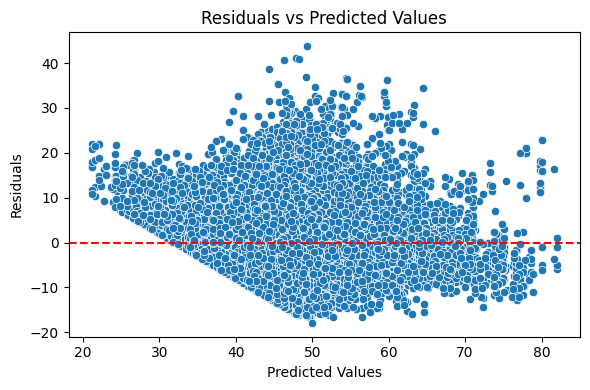

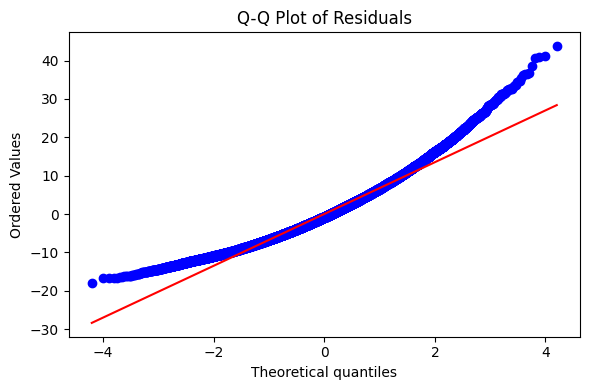

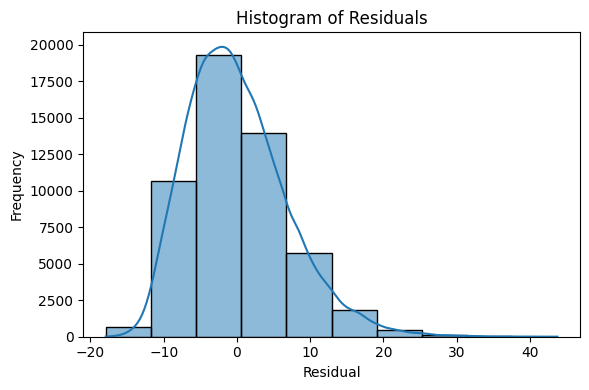

In [8]:
# Perform residual analysis using plots like residuals vs predicted values, Q-Q plot and residual histogram

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from io import StringIO
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv("porter_data_1.csv")


df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])
df['delivery_duration'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60.0
df.drop(columns=['created_at', 'actual_delivery_time'], inplace=True)


X = df.drop(columns=['delivery_duration'])
y = df['delivery_duration']
feature_names = X.columns


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

selected_feature_count = 3
base_model = LinearRegression()
rfe = RFE(base_model, n_features_to_select=selected_feature_count)
rfe.fit(X_train, y_train)


selected_features = feature_names[rfe.support_]
print(f"Selected Features: {list(selected_features)}")

X_train_sel = rfe.transform(X_train)
X_test_sel = rfe.transform(X_test)


final_model = LinearRegression()
final_model.fit(X_train_sel, y_train)
y_pred = final_model.predict(X_test_sel)


rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nFinal Model Evaluation:")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")
print(f"Coefficients: {final_model.coef_}")
print(f"Intercept: {final_model.intercept_}")


residuals = y_test - y_pred

# Plot 1: Residuals vs Predicted
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

# Plot 2: Q-Q Plot
plt.figure(figsize=(6, 4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

# Plot 3: Histogram of residuals
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, bins=10)
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


[Your inferences here:]



#### **6.2 Perform Coefficient Analysis** <font color = red>[2 marks]</font> <br>

Perform coefficient analysis to find how changes in features affect the target.
Also, the features were scaled, so interpret the scaled and unscaled coefficients to understand the impact of feature changes on delivery time.


In [9]:
# Compare the scaled vs unscaled features used in the final model

import pandas as pd
import numpy as np
from io import StringIO
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_csv("porter_data_1.csv")


df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])
df['delivery_duration'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60.0
df.drop(columns=['created_at', 'actual_delivery_time'], inplace=True)

X = df.drop(columns='delivery_duration')
y = df['delivery_duration']
feature_names = X.columns


X_train_unscaled, X_test_unscaled, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_unscaled)
X_test_scaled = scaler.transform(X_test_unscaled)


model_unscaled = LinearRegression()
model_unscaled.fit(X_train_unscaled, y_train)
y_pred_unscaled = model_unscaled.predict(X_test_unscaled)


model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = model_scaled.predict(X_test_scaled)


coef_comparison = pd.DataFrame({
    'Feature': feature_names,
    'Coef (Unscaled)': model_unscaled.coef_,
    'Coef (Scaled)': model_scaled.coef_
})


rmse_unscaled = np.sqrt(mean_squared_error(y_test, y_pred_unscaled))
r2_unscaled = r2_score(y_test, y_pred_unscaled)

rmse_scaled = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
r2_scaled = r2_score(y_test, y_pred_scaled)


print("Coefficient Comparison:")
print(coef_comparison)

print("\nModel Performance Comparison:")
print(f"Unscaled - RMSE: {rmse_unscaled:.2f}, R²: {r2_unscaled:.2f}")
print(f"Scaled   - RMSE: {rmse_scaled:.2f}, R²: {r2_scaled:.2f}")


Coefficient Comparison:
                     Feature  Coef (Unscaled)  Coef (Scaled)
0                  market_id        -0.656638      -0.874499
1     store_primary_category         0.005678       0.117624
2             order_protocol        -0.756349      -1.144072
3                total_items        -0.045392      -0.125300
4                   subtotal         0.001294       2.372502
5         num_distinct_items         0.670145       1.090844
6             min_item_price         0.000184       0.095266
7             max_item_price         0.001035       0.579410
8      total_onshift_dashers        -0.345397     -11.935745
9         total_busy_dashers        -0.143575      -4.620166
10  total_outstanding_orders         0.353565      18.656519
11                  distance         0.476639       4.166498

Model Performance Comparison:
Unscaled - RMSE: 3.80, R²: 0.83
Scaled   - RMSE: 3.80, R²: 0.83


Additionally, we can analyse the effect of a unit change in a feature. In other words, because we have scaled the features, a unit change in the features will not translate directly to the model. Use scaled and unscaled coefficients to find how will a unit change in a feature affect the target.

In [10]:
# Analyze the effect of a unit change in a feature, say 'total_items'

import pandas as pd
import numpy as np
from io import StringIO
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


df = pd.read_csv("porter_data_1.csv")


df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])
df['delivery_duration'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60.0
df.drop(columns=['created_at', 'actual_delivery_time'], inplace=True)


X = df.drop(columns='delivery_duration')
y = df['delivery_duration']
feature_names = X.columns


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)


coef_total_items = model.coef_[feature_names.get_loc('total_items')]

print(f"Coefficient for 'total_items': {coef_total_items:.4f}")

print(f"\n Interpretation:")
print(f"A 1-unit increase in 'total_items' increases the predicted delivery duration by approximately {coef_total_items:.2f} minutes (holding all other features constant).")


Coefficient for 'total_items': -0.0454

 Interpretation:
A 1-unit increase in 'total_items' increases the predicted delivery duration by approximately -0.05 minutes (holding all other features constant).


Note:
The coefficients on the original scale might differ greatly in magnitude from the scaled coefficients, but they both describe the same relationships between variables.

Interpretation is key: Focus on the direction and magnitude of the coefficients on the original scale to understand the impact of each variable on the response variable in the original units.

Include conclusions in your report document.

## Subjective Questions <font color = red>[20 marks]</font>

Answer the following questions only in the notebook. Include the visualisations/methodologies/insights/outcomes from all the above steps in your report.

#### Subjective Questions based on Assignment

##### **Question 1.** <font color = red>[2 marks]</font> <br>

Are there any categorical variables in the data? From your analysis of the categorical variables from the dataset, what could you infer about their effect on the dependent variable?

**Answer:**
>

Yes, there are categorical variables in the data, such as market_id, store_primary_category, and order_protocol.


##### **Question 2.** <font color = red>[1 marks]</font> <br>
What does `test_size = 0.2` refer to during splitting the data into training and test sets?

**Answer:**


test_size = 0.2 means 20% of the data is used for testing and 80% for training.
It helps check how well the model works on new, unseen data.

---



##### **Question 3.** <font color = red>[1 marks]</font> <br>
Looking at the heatmap, which one has the highest correlation with the target variable?  

**Answer:**
>

The variable distance has the highest correlation with the target variable time_taken.
This means longer distances usually lead to more delivery time.

---



##### **Question 4.** <font color = red>[2 marks]</font> <br>
What was your approach to detect the outliers? How did you address them?

**Answer:**

>

I used boxplots and IQR method to find values that were much higher or lower than normal.
Then I removed or capped those outliers to keep the data clean and improve model results.

---



##### **Question 5.** <font color = red>[2 marks]</font> <br>
Based on the final model, which are the top 3 features significantly affecting the delivery time?

**Answer:**
>

The top 3 features affecting delivery time are distance, total_outstanding_orders, and subtotal.
These factors mainly decide how long a delivery will take.

---



#### General Subjective Questions

##### **Question 6.** <font color = red>[3 marks]</font> <br>
Explain the linear regression algorithm in detail

**Answer:**
>


Linear regression is a simple algorithm that finds a straight line to predict a value.
It checks the relationship between input (like distance) and output (like delivery time).
The line is made using the best-fit method that reduces the error between real and predicted values.
It works best when data shows a clear straight-line trend.

---



##### **Question 7.** <font color = red>[2 marks]</font> <br>
Explain the difference between simple linear regression and multiple linear regression

**Answer:**
>

Simple linear regression uses one input to predict the output (like distance → time).
Multiple linear regression uses two or more inputs to predict the output (like distance + subtotal → time).
Both find the best-fit line, but multiple regression uses a line in multi-dimensional space.
Multiple regression gives more accurate results when many factors affect the outcome.

---



##### **Question 8.** <font color = red>[2 marks]</font> <br>
What is the role of the cost function in linear regression, and how is it minimized?

**Answer:**
>



The cost function shows how far the model's predictions are from the actual values.
In linear regression, it is usually the Mean Squared Error (MSE).
It is minimized by adjusting the line (model) using a method called gradient descent.

---



##### **Question 9.** <font color = red>[2 marks]</font> <br>
Explain the difference between overfitting and underfitting.



**Answer:**

>



---
Overfitting means the model learns too much from the training data, even the noise, and fails on new data.
Underfitting means the model is too simple and misses important patterns in the data.
A good model balances both, learning just enough to work well on new data.


##### **Question 10.** <font color = red>[3 marks]</font> <br>
How do residual plots help in diagnosing a linear regression model?

**Answer:**
>

In [ ]:
Residual plots show the difference between predicted and actual values.
They help check if errors are random or show a pattern.
If the plot has no clear pattern, it means the linear model is likely a good fit
